<a href="https://colab.research.google.com/github/i-Yeee/Ml/blob/main/linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pf =pd.read_csv("car-sales.csv")

In [ ]:
pf.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000.0
1,Honda,Red,87899,4,5000.0
2,Toyota,Blue,32549,3,7000.0
3,BMW,Black,11179,5,22000.0
4,Nissan,White,213095,4,3500.0


In [ ]:
pf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           10 non-null     object 
 1   Colour         10 non-null     object 
 2   Odometer (KM)  10 non-null     int64  
 3   Doors          10 non-null     int64  
 4   Price          10 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 532.0+ bytes


In [ ]:
pf.describe()

,Odometer (KM),Doors,Price
count,10.000000,10.000000,10.000000
mean,78601.400000,4.000000,7645.000000
std,61983.471735,0.471405,5379.407753
min,11179.000000,3.000000,3500.000000
25%,35836.250000,4.000000,4625.000000
50%,57369.000000,4.000000,6625.000000
75%,96384.500000,4.000000,7375.000000
max,213095.000000,5.000000,22000.000000


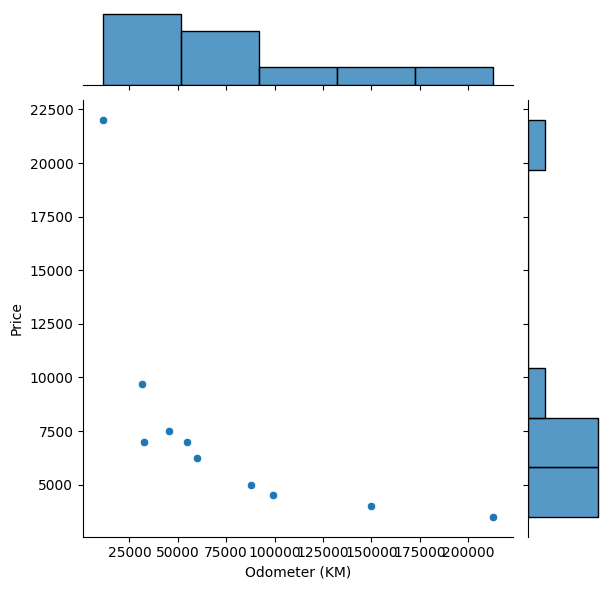

In [ ]:
sns.jointplot(x="Odometer (KM)",y="Price", data=pf)

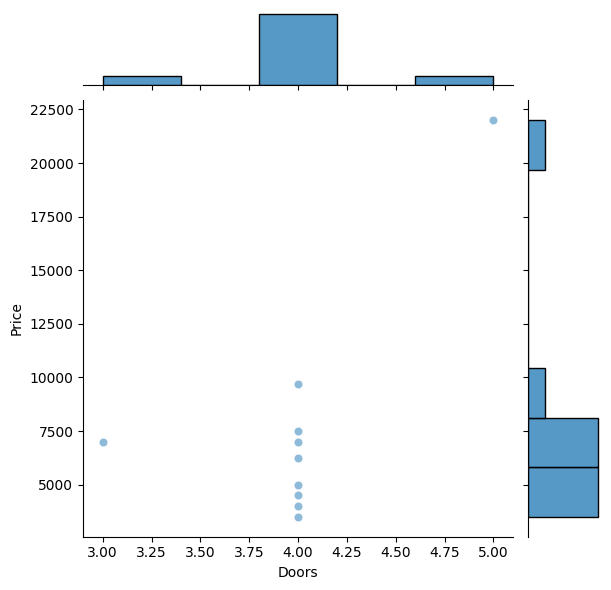

In [ ]:
sns.jointplot(x="Doors",y="Price",data=pf,alpha=0.5)

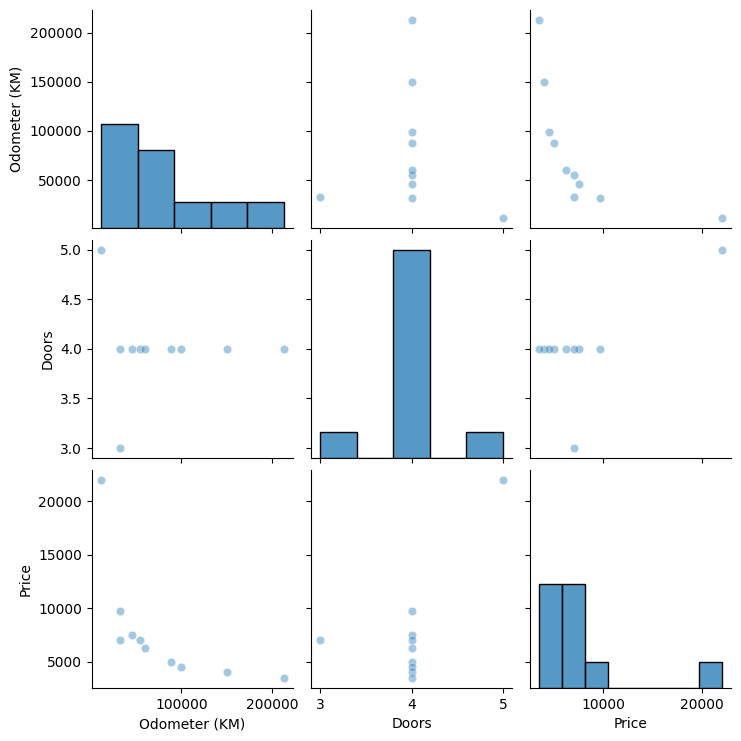

In [ ]:
sns.pairplot(pf,kind='scatter', plot_kws={'alpha':0.4})

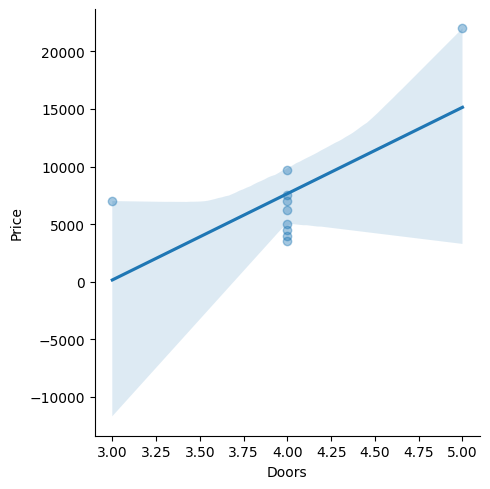

In [ ]:
sns.lmplot(x='Doors',
           y= 'Price',
           data=pf,
           scatter_kws={'alpha':0.4})

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=pf[['Doors', 'Odometer (KM)']]
X

,Doors,Odometer (KM)
0,4,150043
1,4,87899
2,3,32549
3,5,11179
4,4,213095
5,4,99213
6,4,45698
7,4,54738
8,4,60000
9,4,31600


In [ ]:
X=pf[['Doors', 'Odometer (KM)']]
y=pf['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.3, random_state=42)

In [ ]:
#Model training
from sklearn.linear_model import LinearRegression

In [ ]:
lm = LinearRegression()

In [ ]:
lm.fit(X_train, y_train)

LinearRegression()

In [ ]:
lm.coef_

array([ 6.96993611e+03, -4.96082257e-02])

In [ ]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns =['Coef'])
print(cdf)

                      Coef
Doors          6969.936108
Odometer (KM)    -0.049608


In [ ]:
#predictions

In [ ]:
predictions = lm.predict(X_test)

In [ ]:
predictions

array([9514.07389377, 8130.05400398, 7568.78653801])

Text(0.5, 0, 'Predictions')

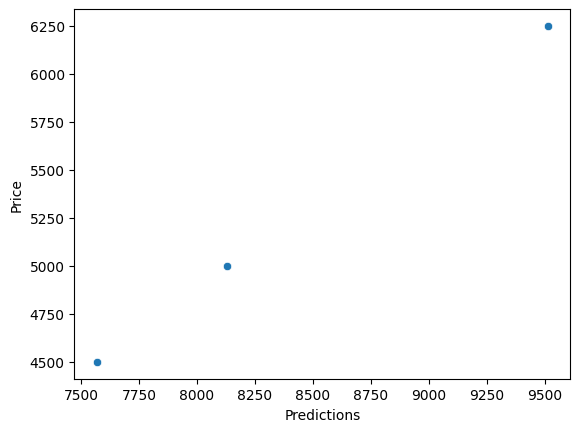

In [ ]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel('Predictions')

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [ ]:
print('Mean Absolute Error: ', mean_absolute_error(y_test, predictions))
print('Mean Squared Error: ', mean_squared_error(y_test, predictions))
print('Root Mean Squared Error: ', math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  3154.304811919192
Mean Squared Error:  9956289.08922597
Root Mean Squared Error:  3155.358789302093


In [ ]:
#Residauls

In [ ]:
residuals = y_test - predictions

In [ ]:
residuals

,Price
8,-3264.073894
1,-3130.054004
5,-3068.786538


In [ ]:
#normality test

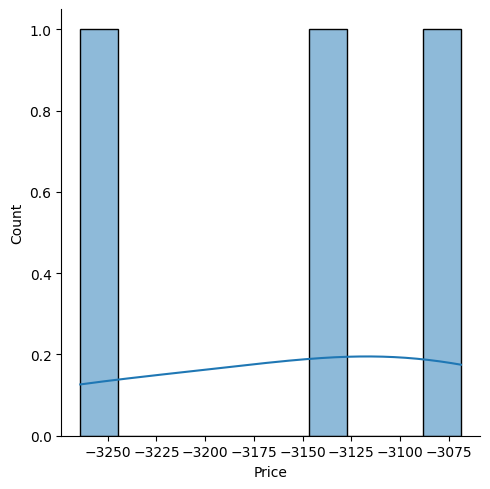

In [ ]:
sns.displot(residuals,bins =10, kde=True)

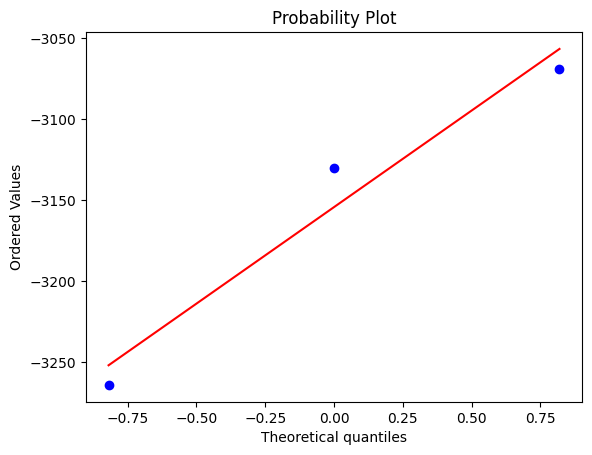

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [ ]:
# FIN